ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [5]:
# Import Libraries/content/medical_students_dataset.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [6]:
# Load Dataset
df = pd.read_csv("/content/medical_students_dataset.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199994,99995.0,22.0,Male,159.486907,NaN,A,27.631082,98.971976,86.0,134.0,208.0,No,NaN
199995,NaN,24.0,Male,176.503260,95.756997,B,30.737254,99.170685,65.0,121.0,130.0,No,No
199996,99997.0,29.0,Female,163.917675,45.225194,NaN,16.831734,97.865785,62.0,125.0,198.0,No,Yes
199997,99998.0,34.0,Female,NaN,99.648914,NaN,33.189303,98.768210,60.0,90.0,154.0,NaN,No


### Check Missing Values

In [7]:
# Check all values
print(df.isna())

        Student ID    Age  Gender  Height  Weight  Blood Type    BMI  \
0            False  False   False   False   False       False  False   
1            False   True   False   False   False       False   True   
2            False  False   False   False   False       False  False   
3             True  False   False   False   False       False  False   
4            False  False   False    True   False       False   True   
...            ...    ...     ...     ...     ...         ...    ...   
199995        True  False   False   False   False       False  False   
199996       False  False   False   False   False        True  False   
199997       False  False   False    True   False        True  False   
199998       False  False   False   False   False       False  False   
199999       False  False   False   False   False       False  False   

        Temperature  Heart Rate  Blood Pressure  Cholesterol  Diabetes  \
0              True       False           False        False 

In [8]:
print(df.isna().sum())

Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64


### Check duplicate rows

In [9]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0
100007,True
100011,True
100018,True
100022,True
100023,True
...,...
199961,True
199962,True
199965,True
199973,True


### No. of rows and columns

In [10]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (200000, 13) 

number of rows:  200000
number of columns:  13


### Data type of columns

In [11]:
# viewing the data types of columns
df.dtypes

,0
Student ID,float64
Age,float64
Gender,object
Height,float64
Weight,float64
Blood Type,object
BMI,float64
Temperature,float64
Heart Rate,float64
Blood Pressure,float64


## Data Cleaning

### Why Data Cleaning Was Needed


- Missing values in many columns such as Age, Height, BMI, Temperature, and Smoking.
- A large number of duplicate rows were found in the dataset.
- The `Student ID` column contained many missing values and did not provide useful information for analysis.


---

### Cleaning Steps Performed

The following steps were applied to clean the dataset:

1. **Handling Missing Values**
   - Numerical columns (Age, Height, Weight, BMI, Temperature, Heart Rate, Blood Pressure, Cholesterol) were filled using the **median**.
   - Categorical columns (Gender, Blood Type, Diabetes, Smoking) were filled using the **mode**.

2. **Removing Duplicate Rows**
   - Duplicate records were identified and removed to ensure each row represents a unique student.

3. **Dropping Irrelevant Column**
   - The `Student ID` column was removed because:
     - It contained many missing values
     - It is only an identifier and does not contribute to analysis

---

### Before and After Cleaning

- Before cleaning:
  - Missing values in multiple columns
  - Duplicate rows
  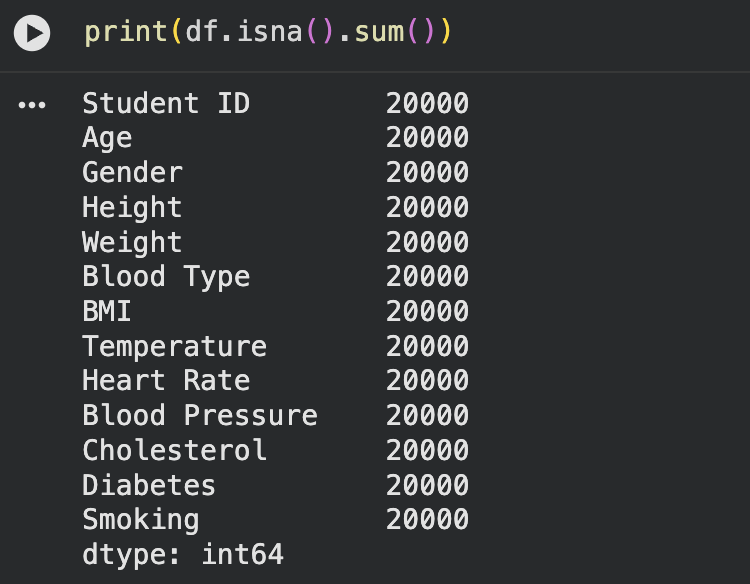

- After cleaning:
  - All missing values were handled
  - All duplicate rows were removed
  - Dataset became consistent and ready for analysis
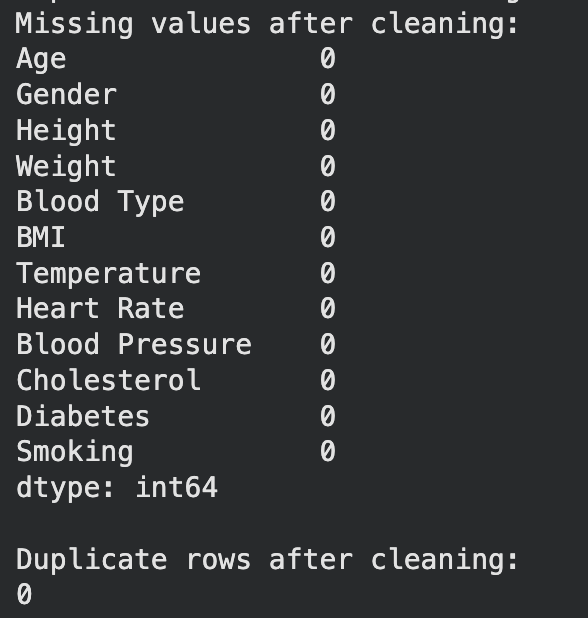

---

### Summary of Changes

After cleaning, the dataset contained:
- No missing values
- No duplicate rows
- Properly formatted data

This ensured that the dataset is reliable for visualization and further analysis.

In [12]:
df_clean = df.copy()

# duplicates before cleaning
print("Duplicate rows before cleaning:", df_clean.duplicated().sum())

# Removing duplicates
df_clean = df_clean.drop_duplicates()

# Filling missing numerical columns with median
num_cols = ['Age', 'Height', 'Weight', 'BMI', 'Temperature',
            'Heart Rate', 'Blood Pressure', 'Cholesterol']

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Filling missing categorical columns with mode
cat_cols = ['Gender', 'Blood Type', 'Diabetes', 'Smoking']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Droping Student ID becaused
df_clean = df_clean.drop(columns=['Student ID'])

# Remove duplicates again after filling missing values
df_clean = df_clean.drop_duplicates()

# Final check
print("Missing values after cleaning:")
print(df_clean.isna().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

# Preview cleaned data
df_clean.head()

Duplicate rows before cleaning: 7644
Missing values after cleaning:
Age               0
Gender            0
Height            0
Weight            0
Blood Type        0
BMI               0
Temperature       0
Heart Rate        0
Blood Pressure    0
Cholesterol       0
Diabetes          0
Smoking           0
dtype: int64

Duplicate rows after cleaning:
0


,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,18.0,Female,161.777924,72.354947,O,27.645835,98.599527,95.0,109.0,203.0,No,No
1,26.0,Male,152.069157,47.630941,B,22.670746,98.714977,93.0,104.0,163.0,No,No
2,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,23.0,Female,174.920345,46.234173,O,22.670746,98.480008,95.0,115.0,231.0,No,No


### Descriptive summary Statistics

In [13]:
# Statistical summary
df_clean.describe(include='all')

,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
count,184336.000000,184336,184336.000000,184336.000000,184336,184336.000000,184336.000000,184336.000000,184336.000000,184336.000000,184336,184336
unique,NaN,2,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,Female,NaN,NaN,O,NaN,NaN,NaN,NaN,NaN,No,No
freq,NaN,101346,NaN,NaN,60856,NaN,NaN,NaN,NaN,NaN,167594,150926
mean,26.019893,NaN,174.939613,69.988650,NaN,23.272387,98.601101,79.561176,114.607206,184.462330,NaN,NaN
std,4.626218,NaN,13.652373,16.368729,NaN,6.647668,0.472243,10.909248,13.616933,35.483319,NaN,NaN
min,18.000000,NaN,150.000041,40.000578,NaN,10.074837,96.397835,60.000000,90.000000,120.000000,NaN,NaN
25%,22.000000,NaN,163.966897,56.764574,NaN,18.440688,98.310529,71.000000,104.000000,156.000000,NaN,NaN
50%,26.000000,NaN,174.920345,69.995078,NaN,22.670746,98.599527,80.000000,115.000000,184.000000,NaN,NaN
75%,30.000000,NaN,185.952845,83.198054,NaN,27.212410,98.893068,88.000000,126.000000,213.000000,NaN,NaN


###Distribution of Age

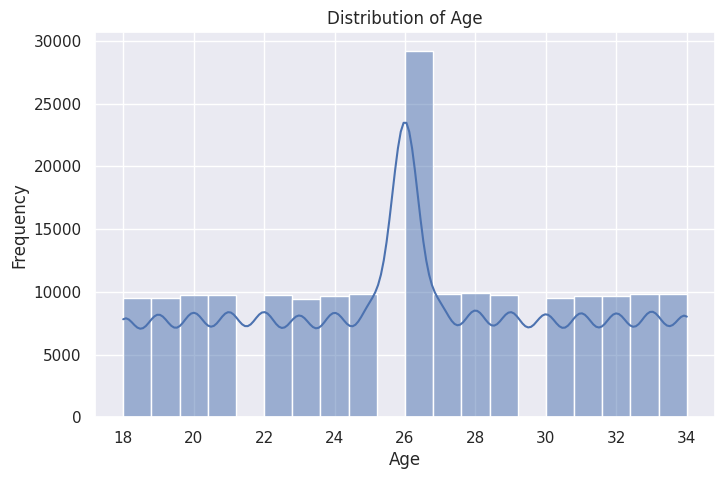

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Age'], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Age Distribution Insights

The age distribution shows that most students fall within a narrow age range, which is expected for a student population.

**Patterns & Trends:**
- The data is concentrated around a central age group.
- There are very few extreme values (outliers).

**What We Learn:**
This indicates that the dataset represents a consistent group of students.

###Distribution of BMI

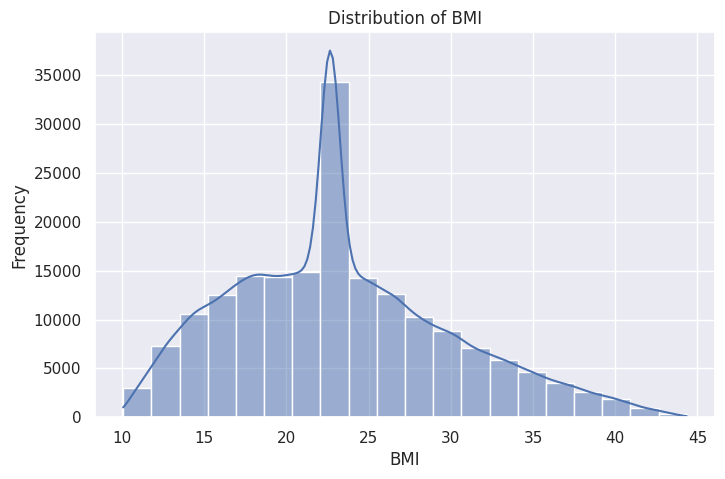

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['BMI'], bins=20, kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

### BMI Distribution Insights

The BMI distribution shows variation in students' body mass index.

**Patterns & Trends:**
- Most BMI values are clustered in a moderate range.
- Some spread exists, indicating differences in body composition.
- slight skewness.

**What We Learn:**
Students have diverse body types, and BMI can be used as an important health indicator for further analysis.

###Distribution of Height

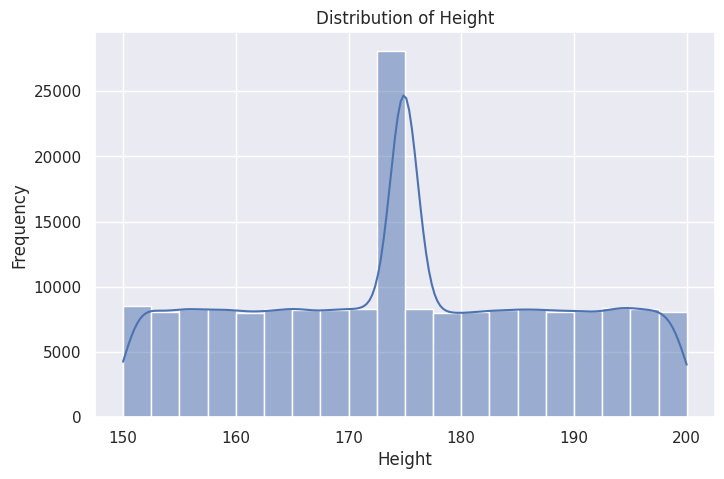

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Height'], bins=20, kde=True)
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

### Height Distribution Insights

The height distribution illustrates how student heights are spread across the dataset.

**Patterns & Trends:**
- Heights are centered around an average value.
- The distribution appears relatively symmetric.
- No extreme outliers are clearly visible.

**What We Learn:**
The dataset reflects a variation in height, which supports reliable comparisons with other variables such as weight and BMI.

###Distribution of Weight

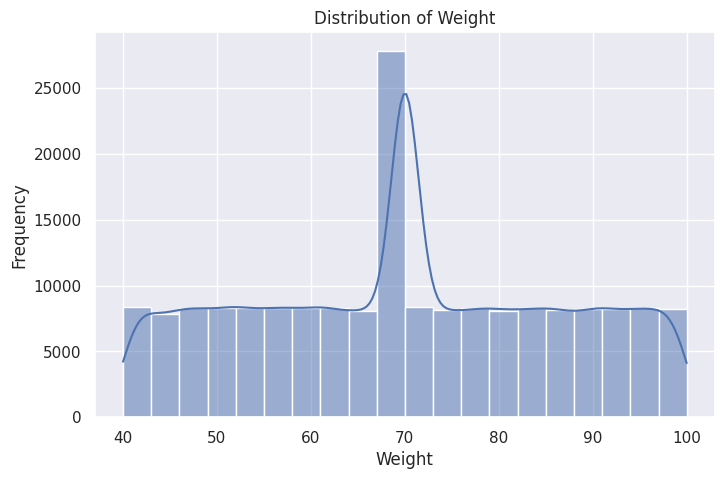

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Weight'], bins=20, kde=True)
plt.title("Distribution of Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

### Weight Distribution Insights

The weight distribution shows how student weights vary.

**Patterns & Trends:**
- Most values fall within a common range.
- Some variation indicates differences in body mass.
- A few higher or lower values may exist.

**What We Learn:**
Weight varies across students, and it plays a key role when analyzed alongside height and BMI.

###Gender Distribution

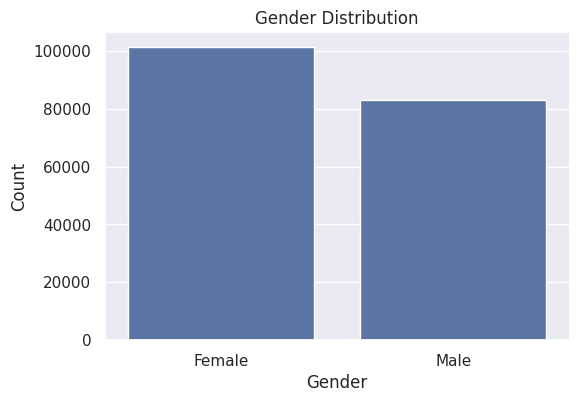

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df_clean)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Gender Distribution - Insights

The gender distribution compares the number of male and female students.

**Patterns & Trends:**
- The dataset balanced and slightly skewed toward Female students.

**What We Learn:**
Understanding gender distribution is important for fairness and for analyzing different characteristics between the two groups.

### Blood Type Distribution

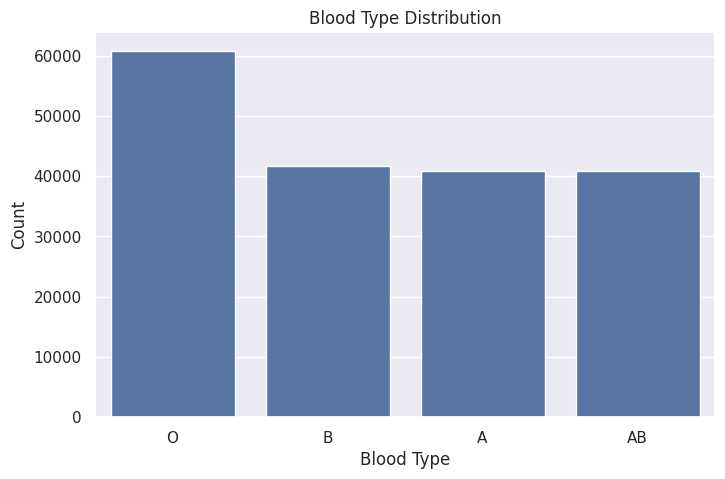

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Blood Type', data=df_clean)
plt.title("Blood Type Distribution")
plt.xlabel("Blood Type")
plt.ylabel("Count")
plt.show()

### Blood Type Distribution Insights

The blood type distribution shows how different blood groups are represented.

**Patterns & Trends:**
- Some blood types are more common than others.
- The distribution reflects natural biological variation.

**What We Learn:**
see the distribution of Blood Types could be useful for medical-related analysis.

###Diabetes Status

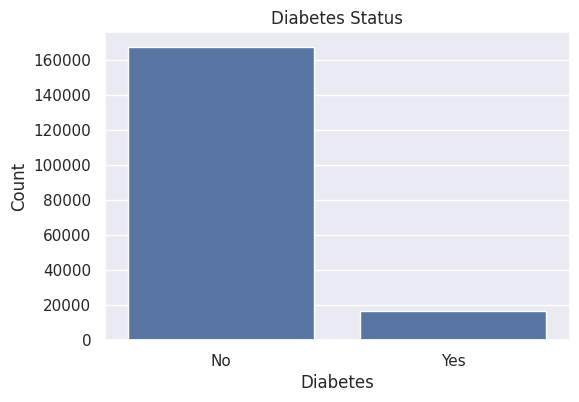

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes', data=df_clean)
plt.title("Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

### Diabetes Status Insights

This plot shows how many students have diabetes compared to those who do not.

**Patterns & Trends:**
- Most students are likely non-diabetic.
- A smaller portion represents diabetic cases.

**What We Learn:**
Diabetes is not very common in this dataset, but it remains an important variable for studying health patterns.

###Smoking Status

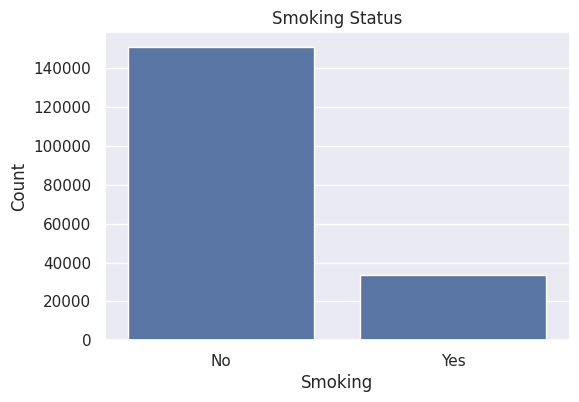

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Smoking', data=df_clean)
plt.title("Smoking Status")
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.show()

### Smoking Status Insights

This visualization compares smokers and non-smokers.

**Patterns & Trends:**
- The majority may be non-smokers.
- A smaller group of students are smokers.

**What We Learn:**
Smoking behavior can be analyzed alongside health indicators like heart rate and cholesterol to identify possible risks.

### Correlation Matrix

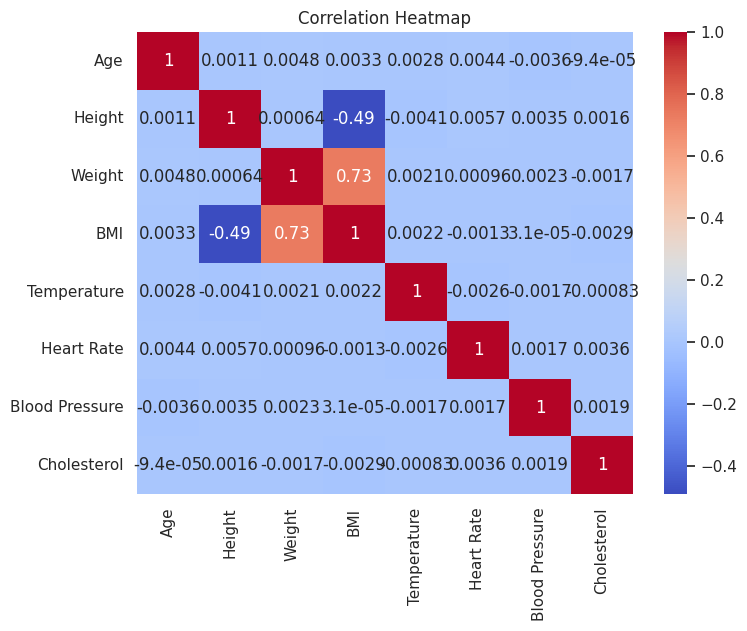

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean[['Age', 'Height', 'Weight', 'BMI', 'Temperature',
              'Heart Rate', 'Blood Pressure', 'Cholesterol']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

### Correlation Heatmap - Insights

The heatmap summarizes relationships between numerical variables.

**Patterns & Trends:**
- Strong correlation between height, weight, and BMI.
- Some variables show weak or no correlation.
- Relationships vary across health indicators.

**What We Learn:**
This helps identify which variables are connected and which are independent, which is useful for future machine learning models.